In [22]:
import jax
import jax.numpy as jnp
import equinox as eqx

import dismech_jax as djx


class ExternalForce(eqx.Module):
    """Linear force: f=mλ+c"""

    m: jax.Array
    c: jax.Array


class Slinky1D(djx.System):
    """Simple 2 node 1D spring."""

    l_k: jax.Array
    ext_f: ExternalForce

    def get_q(self, _lambda: jax.Array, q0: jax.Array) -> jax.Array:
        return q0.at[0].set(0.0)

    def get_E(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        eps = (q[1] - q[0]) / self.l_k - 1.0
        E_int = model(jnp.array([eps]))
        E_ext = -jnp.sum((self.ext_f.m * _lambda + self.ext_f.c) * q)
        return E_int + E_ext

    def get_F(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        mask = jnp.array([0.0, 1.0])
        F = jax.grad(self.get_E, 1)(_lambda, q, model, aux)
        return mask * F

    def get_H(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        mask = jnp.array([0.0, 1.0])
        H = jax.hessian(self.get_E, 1)(_lambda, q, model, aux)
        H = H * mask[:, None] * mask[None, :]
        diag_idx = jnp.arange(H.shape[0])
        return H.at[diag_idx, diag_idx].add(1.0 - mask)  # Ensure non-singular


class SlinkyNN(eqx.Module):
    # MLP weights
    w1: jax.Array
    b1: jax.Array
    w2: jax.Array
    b2: jax.Array
    # Physical priors
    init_k: jax.Array

    def __init__(self, key):
        hidden_size = 10
        k1, k2, k3 = jax.random.split(key, 3)
        self.init_k = jax.random.truncated_normal(k1, 1e-3, 1e1)
        self.w1 = jax.random.normal(k2, (hidden_size, 1)) * 0.01
        self.b1 = jnp.zeros((hidden_size,))
        self.w2 = jax.random.normal(k3, (1, hidden_size)) * 0.01
        self.b2 = jnp.zeros((1,))

    def __call__(self, eps: jax.Array) -> jax.Array:
        k_base = jax.nn.softplus(self.init_k)  # enforce >=0 for learnable K
        base_energy = 0.5 * k_base * (eps**2)
        h = jax.nn.softplus(self.w1 @ eps + self.b1)
        nn_out = jax.nn.softplus(self.w2 @ h + self.b2)
        nn_energy = nn_out[0] * (eps**2)
        return (base_energy + nn_energy).squeeze()


data = jnp.load("slinky.npz")
lambdas = data["lambdas"][::10]
truth = data["qs"][::10]

q0 = truth[0]
l_k0 = q0[1] - q0[0]
ext_f = ExternalForce(jnp.array([0.0, 120.0]), jnp.array([0.0, 0.0]))
slinky = Slinky1D(l_k0, ext_f)
model = SlinkyNN(jax.random.PRNGKey(42))


def loss(model):
    pred = djx.solve(model, lambdas, q0, None, slinky, iters=3, ls_steps=10)
    return jnp.mean((truth - pred) ** 2)

In [23]:
import optax

optimizer = optax.adam(learning_rate=1e-1)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(carry, _):
    model, opt_state = carry
    loss_val, grads = eqx.filter_value_and_grad(loss)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt_state), loss_val


num_epochs = 5000
log_freq = 500


def train_loop(model, opt_state):
    def scan_fn(carry, i):
        next_carry, loss_val = train_step(carry, None)

        def log_loss(_):
            jax.debug.print("Epoch: {x}, Loss: {y}", x=i, y=loss_val)

        jax.lax.cond(i % log_freq == 0, log_loss, lambda _: None, operand=None)
        return next_carry, loss_val

    (final_model, final_opt_state), loss_history = jax.lax.scan(
        scan_fn, (model, opt_state), jnp.arange(num_epochs)
    )
    return final_model, loss_history


final_model, history = train_loop(model, opt_state)

Epoch: 0, Loss: 0.3183375597000122
Epoch: 500, Loss: 0.00018820283003151417
Epoch: 1000, Loss: 0.00010777483112178743
Epoch: 1500, Loss: 3.603487493819557e-05
Epoch: 2000, Loss: 8.499559953634162e-06
Epoch: 2500, Loss: 5.159876764082583e-06
Epoch: 3000, Loss: 3.380550197107368e-06
Epoch: 3500, Loss: 2.453920615153038e-06
Epoch: 4000, Loss: 1.9916126348107355e-06
Epoch: 4500, Loss: 1.7653309214438195e-06


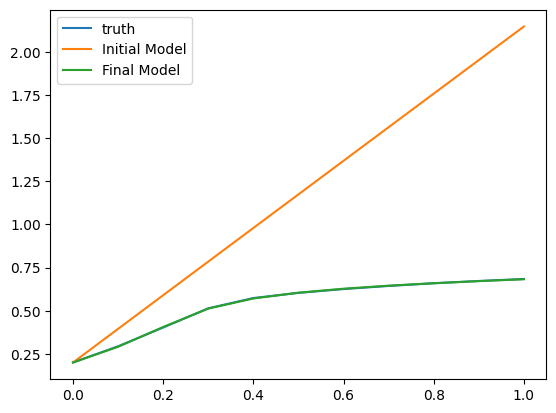

In [24]:
import matplotlib.pyplot as plt

plt.plot(lambdas, truth[:, 1], label="truth")
plt.plot(lambdas, djx.solve(model, lambdas, q0, None, slinky, iters=3, ls_steps=5)[:, 1], label="Initial Model")
plt.plot(lambdas, djx.solve(final_model, lambdas, q0, None, slinky, iters=3, ls_steps=5)[:, 1], label="Final Model")
plt.legend()
plt.show()